In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv('/content/WA_Fn_UseC_Telco_Customer_Churn.csv')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data['TotalCharges']=pd.to_numeric(data['TotalCharges'],errors='coerce')

In [ ]:
data=data[['customerID','SeniorCitizen','Dependents','tenure','Contract','PaperlessBilling','InternetService','OnlineSecurity','TechSupport','StreamingMovies','MonthlyCharges','TotalCharges','Churn']]

In [ ]:
data.head(6)

,customerID,SeniorCitizen,Dependents,tenure,Contract,PaperlessBilling,InternetService,OnlineSecurity,TechSupport,StreamingMovies,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,No,1,Month-to-month,Yes,DSL,No,No,No,29.85,29.85,No
1,5575-GNVDE,0,No,34,One year,No,DSL,Yes,No,No,56.95,1889.50,No
2,3668-QPYBK,0,No,2,Month-to-month,Yes,DSL,Yes,No,No,53.85,108.15,Yes
3,7795-CFOCW,0,No,45,One year,No,DSL,Yes,Yes,No,42.30,1840.75,No
4,9237-HQITU,0,No,2,Month-to-month,Yes,Fiber optic,No,No,No,70.70,151.65,Yes
5,9305-CDSKC,0,No,8,Month-to-month,Yes,Fiber optic,No,No,Yes,99.65,820.50,Yes


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Dependents        7043 non-null   object 
 3   tenure            7043 non-null   int64  
 4   Contract          7043 non-null   object 
 5   PaperlessBilling  7043 non-null   object 
 6   InternetService   7043 non-null   object 
 7   OnlineSecurity    7043 non-null   object 
 8   TechSupport       7043 non-null   object 
 9   StreamingMovies   7043 non-null   object 
 10  MonthlyCharges    7043 non-null   float64
 11  TotalCharges      7032 non-null   float64
 12  Churn             7043 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 715.4+ KB


In [ ]:
data.isna().sum()

,0
customerID,0
SeniorCitizen,0
Dependents,0
tenure,0
Contract,0
PaperlessBilling,0
InternetService,0
OnlineSecurity,0
TechSupport,0
StreamingMovies,0


In [ ]:
data.loc[data['TotalCharges'].isna()]

,customerID,SeniorCitizen,Dependents,tenure,Contract,PaperlessBilling,InternetService,OnlineSecurity,TechSupport,StreamingMovies,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,Yes,0,Two year,Yes,DSL,Yes,Yes,No,52.55,NaN,No
753,3115-CZMZD,0,Yes,0,Two year,No,No,No internet service,No internet service,No internet service,20.25,NaN,No
936,5709-LVOEQ,0,Yes,0,Two year,No,DSL,Yes,No,Yes,80.85,NaN,No
1082,4367-NUYAO,0,Yes,0,Two year,No,No,No internet service,No internet service,No internet service,25.75,NaN,No
1340,1371-DWPAZ,0,Yes,0,Two year,No,DSL,Yes,Yes,No,56.05,NaN,No
3331,7644-OMVMY,0,Yes,0,Two year,No,No,No internet service,No internet service,No internet service,19.85,NaN,No
3826,3213-VVOLG,0,Yes,0,Two year,No,No,No internet service,No internet service,No internet service,25.35,NaN,No
4380,2520-SGTTA,0,Yes,0,Two year,No,No,No internet service,No internet service,No internet service,20.00,NaN,No
5218,2923-ARZLG,0,Yes,0,One year,Yes,No,No internet service,No internet service,No internet service,19.70,NaN,No
6670,4075-WKNIU,0,Yes,0,Two year,No,DSL,No,Yes,No,73.35,NaN,No


### I don't want to delete the column that contains nan because I want to utilize the columns, and also because they are still in the company and I want to use the column MonthlyCharges



In [ ]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## Now we want to see how customers in our company is dependent


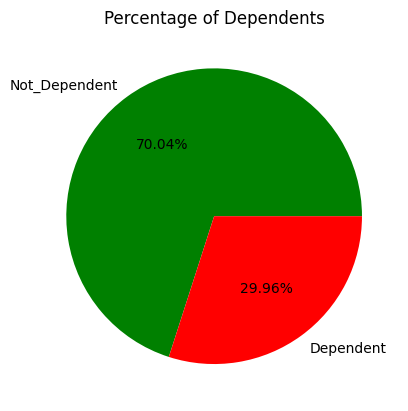

In [66]:
lab=['Dependent' if i =='Yes' else 'Not_Dependent' for i in data['Dependents'].value_counts().index]
plt.pie(data['Dependents'].value_counts(),labels=lab,autopct='%1.2f%%',colors=['g','r'])
plt.title('Percentage of Dependents')
plt.show()

## First i want to focus on the people who left the company, and the most important question is why.




In [ ]:
Subscribers=data['Churn'].value_counts()
Subscribers

,count
Churn,
No,5174
Yes,1869


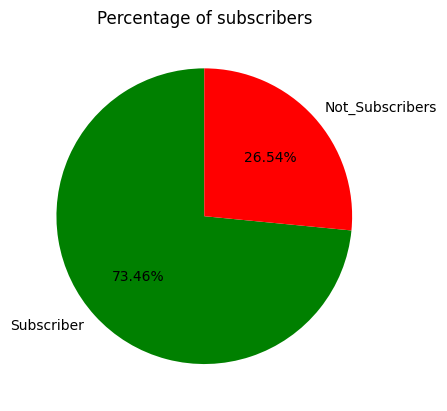

In [ ]:
the_label=['Subscriber' if i =='No' else 'Not_Subscribers' for i in Subscribers.index]
plt.pie(Subscribers,labels=the_label,autopct='%1.2f%%',startangle=90,colors=['g','r'])
plt.title('Percentage of subscribers')
plt.show ()

In [ ]:
Not_Subscribers=data.loc[data['Churn']=='Yes']
Not_Subscribers

,customerID,SeniorCitizen,Dependents,tenure,Contract,PaperlessBilling,InternetService,OnlineSecurity,TechSupport,StreamingMovies,MonthlyCharges,TotalCharges,Churn
2,3668-QPYBK,0,No,2,Month-to-month,Yes,DSL,Yes,No,No,53.85,108.15,Yes
4,9237-HQITU,0,No,2,Month-to-month,Yes,Fiber optic,No,No,No,70.70,151.65,Yes
5,9305-CDSKC,0,No,8,Month-to-month,Yes,Fiber optic,No,No,Yes,99.65,820.50,Yes
8,7892-POOKP,0,No,28,Month-to-month,Yes,Fiber optic,No,Yes,Yes,104.80,3046.05,Yes
13,0280-XJGEX,0,No,49,Month-to-month,Yes,Fiber optic,No,No,Yes,103.70,5036.30,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7021,1699-HPSBG,0,No,12,One year,Yes,DSL,No,Yes,No,59.80,727.80,Yes
7026,8775-CEBBJ,0,No,9,Month-to-month,Yes,DSL,No,No,No,44.20,403.35,Yes
7032,6894-LFHLY,1,No,1,Month-to-month,Yes,Fiber optic,No,No,No,75.75,75.75,Yes
7034,0639-TSIQW,0,No,67,Month-to-month,Yes,Fiber optic,Yes,No,No,102.95,6886.25,Yes


In [ ]:
Not_Subscribers.pivot_table(index='Contract' , columns=['InternetService'], values=['customerID'],aggfunc={'customerID':'count'})

customerID                
InternetService        DSL Fiber optic  No
Contract                                  
Month-to-month         394        1162  99
One year                53         104   9
Two year                12          31   5

## Here we observe something very important: the shorter the contract, the higher the rate of subscriber leaving the company.
##We also notice something very important: most of those who left were subscribers to the service Fiber optic.
##The question here is why?


In [ ]:
Not_Subscribers.pivot_table(index='InternetService',values='MonthlyCharges',aggfunc='mean')

,MonthlyCharges
InternetService,
DSL,49.083224
Fiber optic,88.126484
No,20.368142


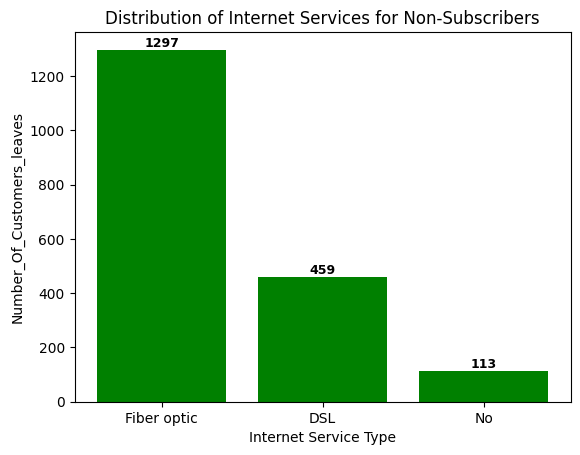

In [ ]:
Number_Of_Customers_leaves = Not_Subscribers['InternetService'].value_counts()
x_labels = Number_Of_Customers_leaves.index
y_values = Number_Of_Customers_leaves.values
bars = plt.bar(x_labels, y_values, color='g')
for bar in bars:
    value = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.5, value,
             ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.xlabel('Internet Service Type')
plt.ylabel('Number_Of_Customers_leaves')
plt.title('Distribution of Internet Services for Non-Subscribers')
plt.show()

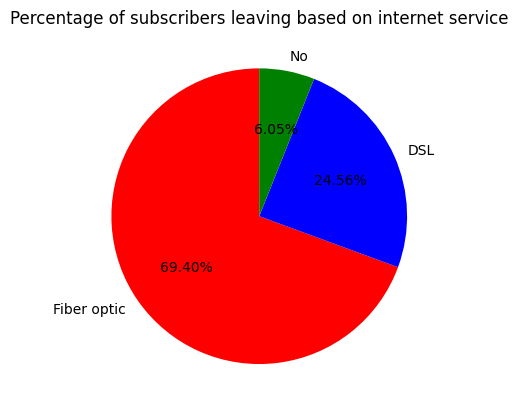

In [ ]:
plt.pie(Not_Subscribers['InternetService'].value_counts(),labels=Not_Subscribers['InternetService'].value_counts().index,autopct='%1.2f%%',startangle=90,colors=['r','b','g'])
plt.title('Percentage of subscribers leaving based on internet service')
plt.show()

##Here we also note that most of those leaving do not have technical support.

In [ ]:
Not_Subscribers.pivot_table(index='TechSupport',values='customerID' ,aggfunc='count')

,customerID
TechSupport,
No,1446
No internet service,113
Yes,310


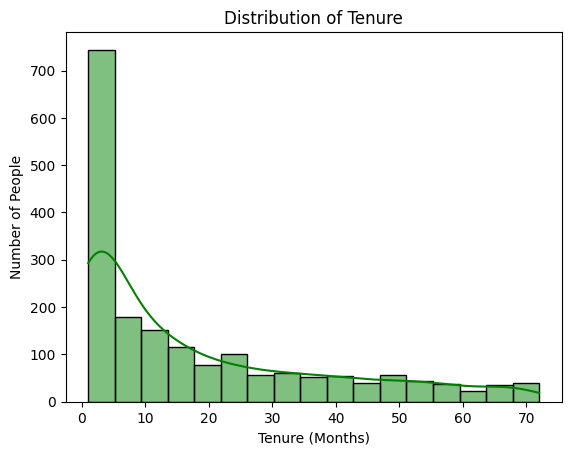

In [ ]:

sns.histplot(data=Not_Subscribers,x='tenure',kde=True,color='g')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of People')
plt.title('Distribution of Tenure')
plt.show()

## In the previous graph, we notice something very important: the highest number of departures occurs in the first few months of membership, and the longer a member stays with the company, the lower the likelihood of them leaving. This is very important.

# in conclusion
###The most important question is how can we reduce the percentage of customers leaving the company?
###1- According to previous analyses, we found that most of those leaving had short-term contracts. We should try to extend contracts as much as possible.
###2- Most of those leaving were subscribers to the Fiber optic service, even though it's the fastest service, it's also the most expensive. We should try to reduce the subscription fees for this service
##But, it's very important to note that the longer the contract for this service Fiber optic, the lower the dropout rate. Therefore, if we want to make a contract for this service, the minimum contract duration should be 1 year.


###3- We also noticed that most of those leaving didn't have TechSupport, so we should provide more maintenance services for customers.
###4- We also noticed that approximately 70% of subscribers are not Dependents. This is clear evidence that most subscribers may be young. We should reduce subscription prices for different services, but without harming the company.

